In [15]:
library("DESeq2")
library("ggplot2")
library("ggrepel")
library("ggcorrplot")
library(CCA)
library("dplyr")
library(stringr)
library(purrr)
library("tibble")
library(dplyr)
library(tidyr)
library(ComplexHeatmap)
library("pals")
library(ggpubr)
library(tximport)
library(DESeq2)
library("apeglm")
library(patchwork)
library(ggrastr)
library(circlize)
library(corrplot)
library(ggrepel)


theme_set(
    theme_classic(base_size = 12)
)
source('./plot_data.R')

In [3]:
chrom_level = c('promoter-accessible', 'intragenic-accessible', 'co-accessible', 'fully-nucleosomal', 'fully-accessible')

In [53]:
delta_chromatin = read.table(file = "../data/5_chromatin_delta_usage_per_gene", sep = "\t", header = T, check.names = FALSE) %>% column_to_rownames("gene_id")
lfc_isoforms = read.table(file = "../data/7_mature_rna_isoform_log2fc_per_gene.tsv", sep = "\t", header = T, check.names = FALSE) %>% column_to_rownames("gene_id")
# lfc_isoforms = read.table(file = "../data/7_nascent_rna_isoform_log2fc_per_gene.tsv", sep = "\t", header = T) %>% column_to_rownames("gene_id")

shared_genes = unique(sort(intersect(rownames(delta_chromatin), rownames(lfc_isoforms))))

chrom_cols <- c("promoter-accessible", "intragenic-accessible",
                "co-accessible", "fully-nucleosomal", "fully-accessible")
iso_cols   <- c("lfc_tss", "lfc_citss", "lfc_atss")

df <- cbind(delta_chromatin[shared_genes, chrom_cols], lfc_isoforms[shared_genes,iso_cols])

df[is.na(df)] = 0


df_scaled <- df %>% mutate(across(all_of(c(chrom_cols, iso_cols)), scale))

chrom_sel <- df_scaled %>% dplyr::select(all_of(chrom_cols))
iso_sel   <- df_scaled %>% dplyr::select(all_of(iso_cols))

cor_mat <- matrix(NA, length(chrom_cols), length(iso_cols),
                  dimnames = list(chrom_cols, iso_cols))
p_mat <- cor_mat

for (r in seq_along(chrom_cols)) {
  for (c in seq_along(iso_cols)) {
    ct <- suppressWarnings(
      cor.test(chrom_sel[[r]], iso_sel[[c]],
               method = "spearman", use = "pairwise.complete.obs")
    )
    cor_mat[r, c] <- ct$estimate
    p_mat[r, c]   <- ct$p.value
  }
}

p_adj <- matrix(p.adjust(p_mat, method = "BH"),
                nrow = nrow(p_mat), dimnames = dimnames(p_mat))

sig_stars <- function(p) {
  ifelse(p < 0.001, "***",
  ifelse(p < 0.01,  "**",
  ifelse(p < 0.05,  "*", "")))
}

pdf 
  2

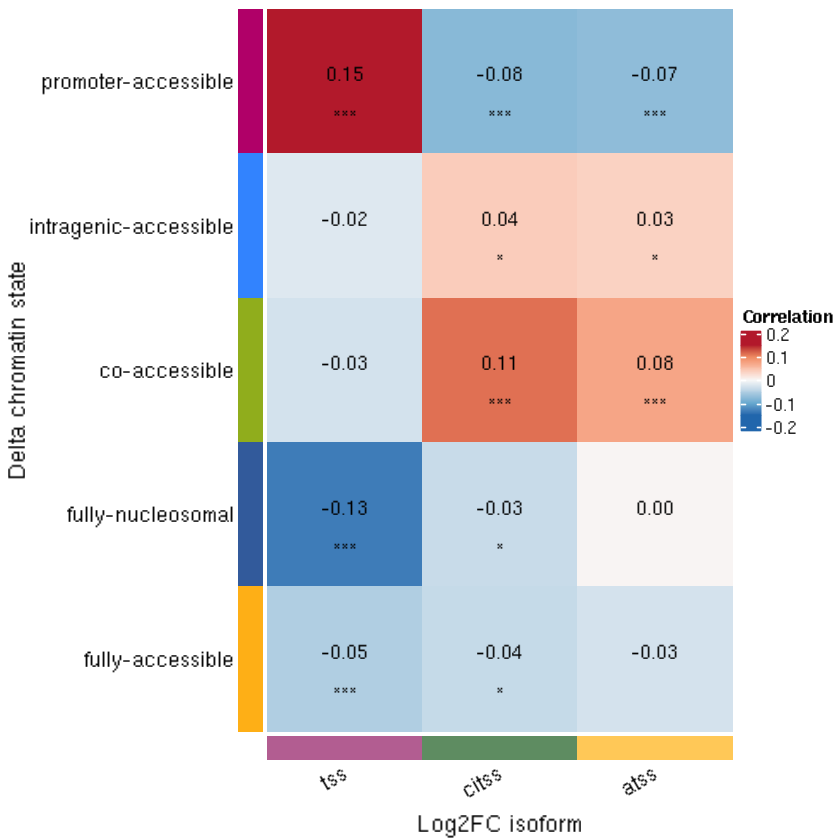

In [70]:
cell_fun = function(j, i, x, y, w, h, fill) {
  grid.text(sprintf("%.2f", cor_mat[i, j]),
            x, y + unit(0.01, "npc"), gp = gpar(fontsize = 11))
  grid.text(sig_stars(p_adj[i, j]),
            x, y + unit(-0.05, "npc"),
            gp = gpar(fontsize = 11))
}


chrom_col <- polychrome()[c(7, 10, 8, 6, 15)]
names(chrom_col) <- c("fully-accessible", "co-accessible", "promoter-accessible",
                     "intragenic-accessible", "fully-nucleosomal")
chrom_col = chrom_col[chrom_level]

cor_mat <- cor_mat[chrom_level, ]
p_adj   <- p_adj[chrom_level, ]

iso_level = c("tss", "citss", "atss")
colnames(cor_mat)<- iso_level
iso_col <- c("#B25D91FF", "#5E8C61FF", "#FFC857FF")
names(iso_col) <- iso_level

row_ha <- rowAnnotation(
  State = chrom_level,
  col   = list(State = chrom_col),
  show_annotation_name = FALSE,
  show_legend = FALSE
)

col_ha <- HeatmapAnnotation(
  State = iso_level,
  col   = list(State = iso_col),
  show_annotation_name = FALSE,
  show_legend = FALSE
)

ht <- Heatmap(cor_mat,
        name = "Correlation",
        cluster_rows = FALSE,
        cluster_columns = FALSE,
        col = colorRamp2(c(-0.15, -0.1, 0, 0.1, 0.15), c("#2166ac", "#67a9cf", "#f7f7f7", "#ef8a62", "#b2182b")),
        row_title = "Delta chromatin state",
        column_title = "Log2FC isoform",
        column_title_side = "bottom",
        column_names_rot = 30,
        show_row_dend = FALSE,
        show_column_dend = FALSE,
        show_row_names = TRUE,
        show_column_names = TRUE,
        column_names_side = "bottom",
        row_names_side = "left",
        left_annotation = row_ha,
        top_annotation = NULL,
        bottom_annotation = col_ha,
        cell_fun = cell_fun)

draw(ht)

pdf('../figures/Supp_spearman_correlation_delta_chromain_and_Log2FC_isoform.pdf', width = 5, height = 4)
draw(ht,      
     column_title = "Spearman correlation\nDelta chromatin states vs Log2FC isoform",
     column_title_gp = gpar(fontsize = 12),
     heatmap_legend_side = "right")
dev.off()

draw(ht, heatmap_legend_side = "right")

## find overlaps between isoform change and chromatin change

In [33]:
counts = read.table(file = "../data/7_mature_rna_tss_count.tsv", sep = "\t", header = TRUE, row.names = 1, check.names = FALSE)
counts_long<- counts %>% 
    mutate(iso_id = rownames(.) %>% str_split_i(pattern = "_", 1)) %>%
    mutate(feature_id = str_split_i(iso_id, pattern = ":", 2), gene_id = str_split_i(iso_id, pattern = ":", 1)) %>% 
    pivot_longer(colnames(counts), names_to = "sample", values_to = "count")

gene_totals <- counts_long %>%
    group_by(gene_id, sample) %>%
    summarise(total = sum(count), .groups = "drop")

iso_usage <- counts_long %>%
    left_join(gene_totals, by = c("gene_id", "sample")) %>%
    mutate(usage = if_else(total > 0, count / total, NA_real_)) %>% 
    dplyr::select(iso_id, feature_id, gene_id, sample, usage) %>%
    pivot_wider(names_from = sample, values_from = usage)

df1<- iso_usage %>%
    mutate(WT_mean = rowMeans(across(c('WT rep1', 'WT rep2', 'WT rep3'))),
          MUT_mean = rowMeans(across(c('MUT rep1', 'MUT rep2', 'MUT rep3'))),
          feature_id = str_split_i(iso_id, ':', 2),
          gene_id = str_split_i(iso_id, ':', 1)
          ) %>% 
    dplyr::select(WT_mean, MUT_mean, feature_id, gene_id) %>% 
    pivot_wider(names_from = feature_id, values_from = c(WT_mean, MUT_mean)) %>% 
    column_to_rownames("gene_id")

chrom_usage<- read.table("../data/supp/260313_diff_nuc_promoter_restricted_usages_table.tsv", sep = "\t", header = TRUE, row.names = 1)

df2<- chrom_usage %>%
    mutate(WT_mean = rowMeans(across(c('WT_rep1', 'WT_rep2'))),
          MUT_mean = rowMeans(across(c('MUT_rep1', 'MUT_rep2'))),
          chrom_state = str_split_i(rownames(.), ':', 2),
          geneid = str_split_i(rownames(.), ':', 1)
          ) %>% 
    dplyr::select(WT_mean, MUT_mean, chrom_state, geneid) %>% 
    pivot_wider(names_from = chrom_state, values_from = c(WT_mean, MUT_mean)) %>% 
    column_to_rownames("geneid")


shared_genes = unique(sort(intersect(rownames(delta_chromatin), rownames(lfc_isoforms))))


chrom_level = c('promoter-accessible', 'intragenic-accessible', 'co-accessible', 'fully-nucleosomal', 'fully-accessible')
iso_cols   <- c("lfc_tss", "lfc_citss", "lfc_atss")
df <- cbind(delta_chromatin[shared_genes,], lfc_isoforms[shared_genes,iso_cols])
df$class<- factor(df$class, levels = c('low', 'medium', 'high'))

df<- cbind(df, df2[rownames(df), ])
df<- cbind(df, df1[rownames(df), ])
df[is.na(df)] = 0

write.table(df, "../data/11_isoform_and_chromatin_state_usage_combined.tsv", sep = "\t", quote = FALSE,col.names = T, row.names = T)